# EDA y verificación de calidad — Base simulada sin faltantes


En este notebook se hace un EDA
completo de la base simulada y verificar que reproduce lo que planteamos en la
Primera entrega (20%-25% de riesgo "malo", dirección de las relaciones
documentadas). La segunda mitad, el `Pipeline` y las líneas base de la Sección
7.2, está en `Pipeline_particion_lineas_base.ipynb`.

Trabajamos sobre `credito_simulado_base.csv`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/simulado/credito_simulado_base.csv")
print(df.shape)
df.head()


(6500, 13)


,id,edad,genero,tipo_ocupacion,tipo_vivienda,nivel_ahorro,saldo_categoria,saldo_cuenta_cop,monto_credito_cop,plazo_meses,proposito_credito,estado_pago_previo,riesgo
0,1,36,M,informal,arrendada,bajo,medio,459000.0,2213000.0,18,electrodomesticos,al_dia,bueno
1,2,41,M,formal_calificado,familiar,alto,sin_cuenta,0.0,4652000.0,15,negocio,al_dia,bueno
2,3,35,F,informal,arrendada,bajo,medio,790000.0,3206000.0,24,libre_inversion,mora_severa,malo
3,4,34,M,informal,arrendada,muy_alto,bajo,116000.0,5969000.0,48,electrodomesticos,mora_severa,bueno
4,5,42,M,informal,arrendada,medio,medio,591000.0,4631000.0,33,remodelacion,al_dia,bueno


## 1. Estructura general

Empezamos revisando tipos de datos y duplicados antes que cualquier otra
cosa, porque un error de tipo o un registro duplicado distorsiona cualquier
estadística que calculemos después.

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  6500 non-null   int64  
 1   edad                6500 non-null   int64  
 2   genero              6500 non-null   str    
 3   tipo_ocupacion      6500 non-null   str    
 4   tipo_vivienda       6500 non-null   str    
 5   nivel_ahorro        6500 non-null   str    
 6   saldo_categoria     6500 non-null   str    
 7   saldo_cuenta_cop    6500 non-null   float64
 8   monto_credito_cop   6500 non-null   float64
 9   plazo_meses         6500 non-null   int64  
 10  proposito_credito   6500 non-null   str    
 11  estado_pago_previo  6500 non-null   str    
 12  riesgo              6500 non-null   str    
dtypes: float64(2), int64(3), str(8)
memory usage: 660.3 KB


In [3]:
# Duplicados: por fila completa y por el identificador `id`
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
print("IDs duplicados:", df["id"].duplicated().sum())
print("IDs únicos:", df["id"].nunique(), "de", len(df), "registros")
print("Valores faltantes en toda la base:", df.isna().sum().sum(),
      "(esperado: 0, esta es la versión sin faltantes)")


Filas duplicadas (todas las columnas): 0
IDs duplicados: 0
IDs únicos: 6500 de 6500 registros
Valores faltantes en toda la base: 0 (esperado: 0, esta es la versión sin faltantes)


## 2. Outliers (valores atípicos)

Usamos el criterio IQR (rango intercuartílico) en vez de una regla basada en
z-score, porque las variables numéricas de esta base (`monto_credito_cop`,
`saldo_cuenta_cop`) son log-normales por diseño, tienen cola larga hacia la
derecha. Un criterio de z-score asume implícitamente simetría, y con datos
así de sesgados terminaría marcando como "atípicos" un montón de valores
altos que en realidad son parte normal de la distribución. El IQR es más
robusto frente a esa asimetría porque se basa en percentiles y no en la
media.

In [4]:
def resumen_outliers_iqr(serie, k=1.5):
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - k * iqr, q3 + k * iqr
    atipicos = (s < lim_inf) | (s > lim_sup)
    return {
        "n_validos": len(s), "lim_inf": lim_inf, "lim_sup": lim_sup,
        "n_atipicos": atipicos.sum(), "%_atipicos": round(atipicos.mean() * 100, 2),
    }

num_cols = ["edad", "saldo_cuenta_cop", "monto_credito_cop", "plazo_meses"]
outliers_df = pd.DataFrame({c: resumen_outliers_iqr(df[c]) for c in num_cols}).T
outliers_df


,n_validos,lim_inf,lim_sup,n_atipicos,%_atipicos
edad,6500.0,12.5,56.5,122.0,1.88
saldo_cuenta_cop,6500.0,-819000.0,1365000.0,635.0,9.77
monto_credito_cop,6500.0,-3090375.0,13236625.0,318.0,4.89
plazo_meses,6500.0,-7.5,52.5,149.0,2.29


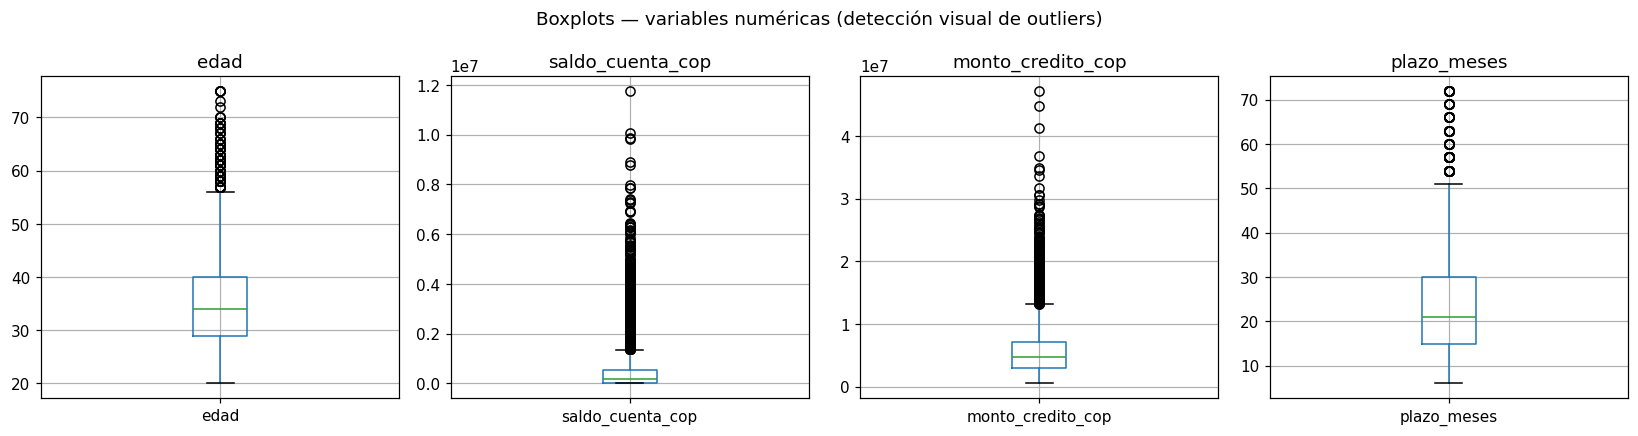

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
fig.suptitle("Boxplots — variables numéricas (detección visual de outliers)")
fig.tight_layout()
plt.show()


**Cómo leer los outliers.** Los valores que el criterio IQR marca como
atípicos en `monto_credito_cop` y `saldo_cuenta_cop` son, en su mayoría,
consecuencia esperada de la forma log-normal de estas variables, es decir
créditos de monto alto pero perfectamente legítimos, no errores de captura, así
que no recomendamos eliminarlos sin más. `edad` y `plazo_meses` están acotadas
por diseño (entre 18 y 75, y entre 4 y 72 meses), así que sus outliers, si
aparecen, son marginales.

## 3. EDA univariado

Separamos numéricas de categóricas porque cada tipo necesita una
visualización distinta, histograma para unas y gráfico de barras de
proporciones para otras, y también una lectura distinta: forma de la
distribución en un caso, balance entre categorías en el otro.

In [6]:
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
edad,6500.0,3.521000e+01,8.287943e+00,20.0,29.0,34.0,40.0,75.0
saldo_cuenta_cop,6500.0,4.969443e+05,9.127805e+05,0.0,0.0,178500.0,546000.0,11765000.0
monto_credito_cop,6500.0,5.652596e+06,3.947122e+06,500000.0,3032250.0,4646000.0,7114000.0,47181000.0
plazo_meses,6500.0,2.414723e+01,1.128093e+01,6.0,15.0,21.0,30.0,72.0


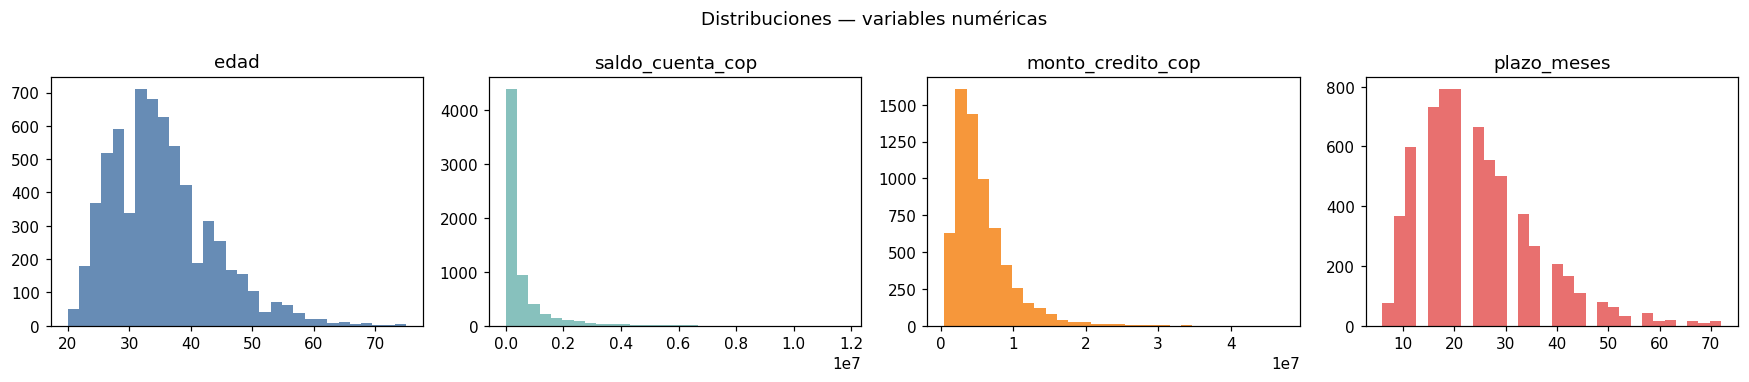

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
colors = ["#4C78A8", "#72B7B2", "#F58518", "#E45756"]
for ax, col, color in zip(axes, num_cols, colors):
    ax.hist(df[col], bins=30, color=color, alpha=0.85)
    ax.set_title(col)
fig.suptitle("Distribuciones — variables numéricas")
fig.tight_layout()
plt.show()


Revisamos las categóricas en proporciones y no en conteos absolutos, porque
con 6.500 registros los conteos son menos fáciles de leer que las proporciones
a la hora de juzgar si una categoría está sub-representada, algo que nos va a
servir para decidir, en la Sección 7.2, si alguna categoría necesita
agruparse antes de la codificación one-hot.

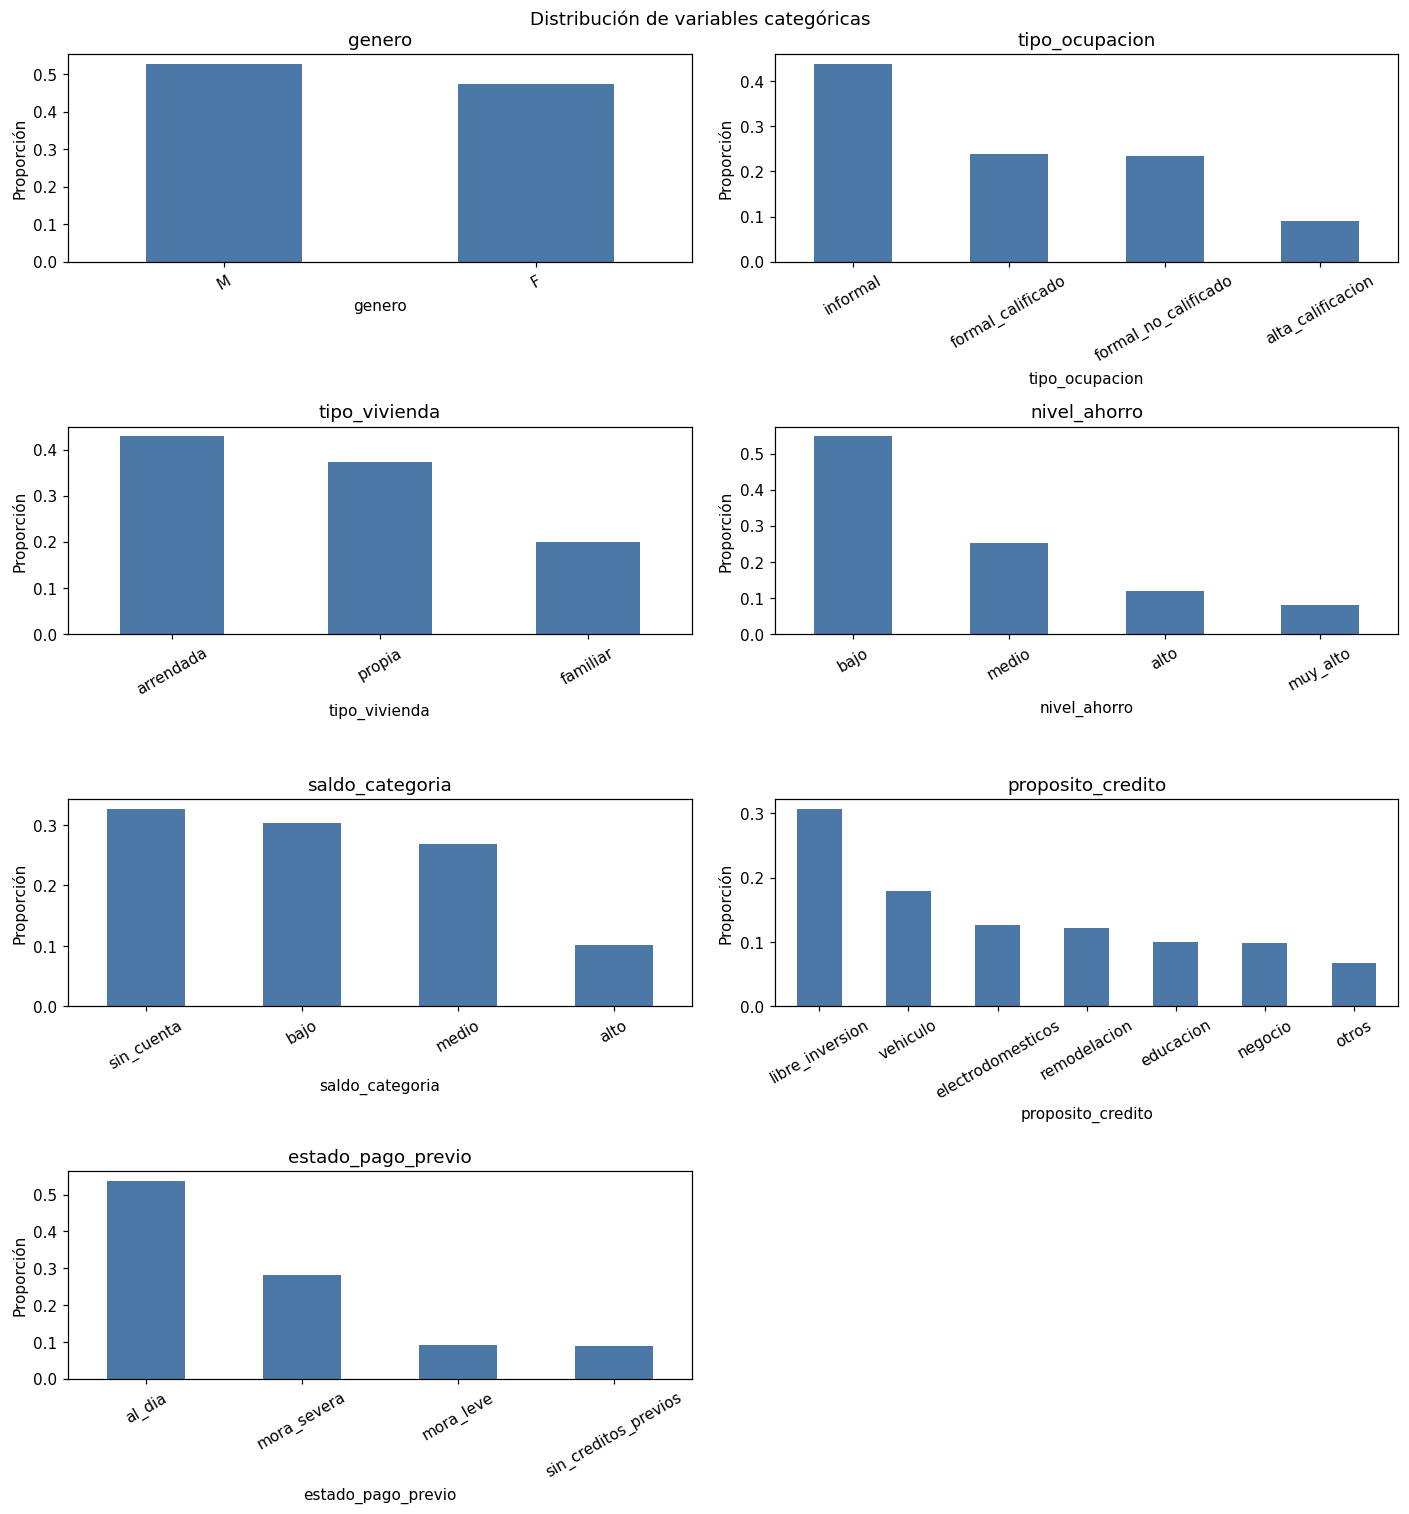

In [8]:
cat_cols = ["genero", "tipo_ocupacion", "tipo_vivienda", "nivel_ahorro",
            "saldo_categoria", "proposito_credito", "estado_pago_previo"]

fig, axes = plt.subplots(4, 2, figsize=(13, 14))
axes = axes.ravel()
for ax, col in zip(axes, cat_cols):
    df[col].value_counts(normalize=True).plot(kind="bar", ax=ax, color="#4C78A8")
    ax.set_title(col)
    ax.set_ylabel("Proporción")
    ax.tick_params(axis="x", rotation=30)
axes[-1].axis("off")
fig.suptitle("Distribución de variables categóricas")
fig.tight_layout()
plt.show()


## 4. EDA bivariado: relación con la variable objetivo

Miramos cada predictor contra `riesgo` antes de ponernos a modelar porque esta
es la evidencia directa de que las variables sí tienen poder predictivo, lo
cual justifica usarlas en el modelo, y sobre todo porque acá es donde de
verdad verificamos que la simulación reprodujo las relaciones que
documentamos en la Primera entrega. No basta con haberlas programado en
`generar_datos_simulados.py`, hay que confirmarlas en los datos que
efectivamente salieron.

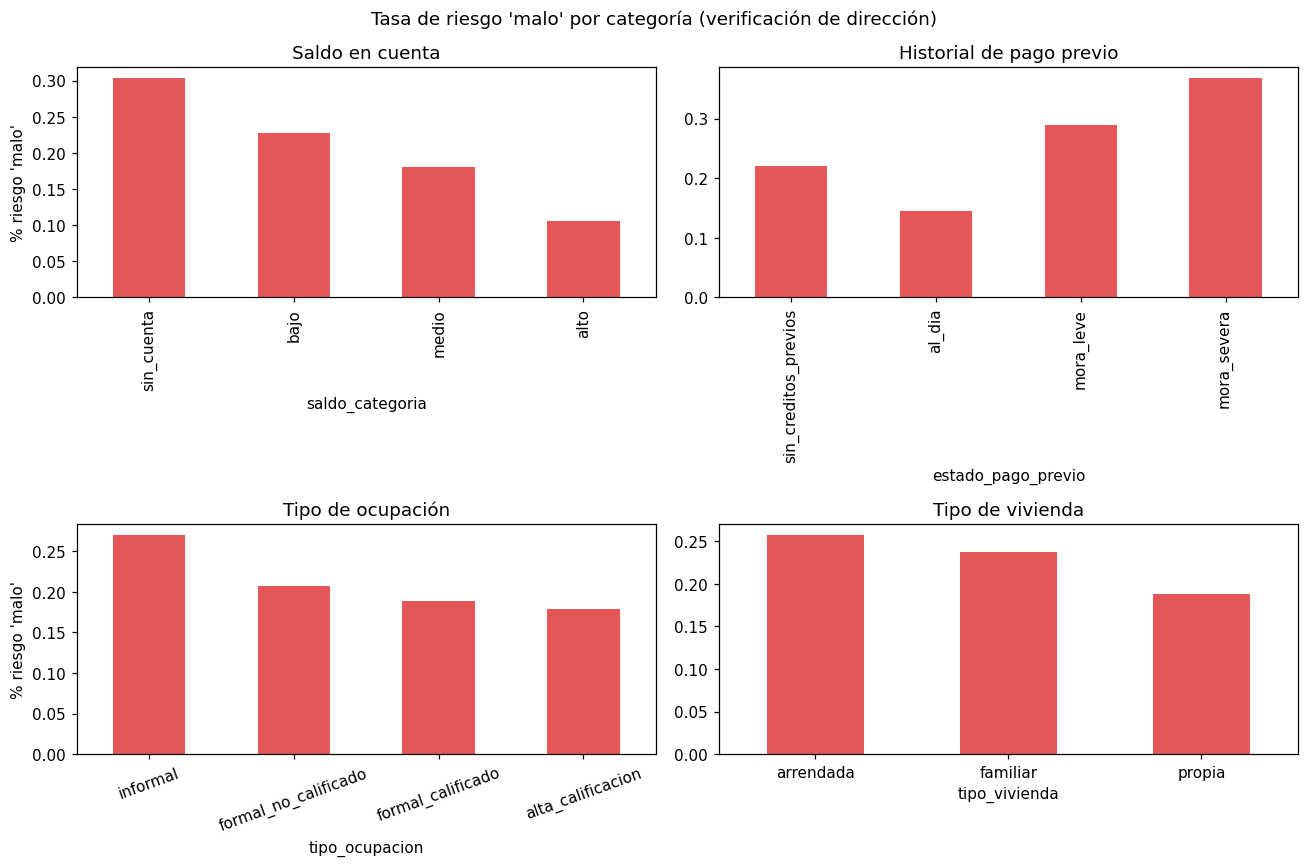

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

t_saldo = df.groupby("saldo_categoria")["riesgo"].apply(lambda s: (s == "malo").mean())
t_saldo = t_saldo.reindex(["sin_cuenta", "bajo", "medio", "alto"])
t_saldo.plot(kind="bar", ax=axes[0, 0], color="#E45756")
axes[0, 0].set_title("Saldo en cuenta")
axes[0, 0].set_ylabel("% riesgo 'malo'")

t_pago = df.groupby("estado_pago_previo")["riesgo"].apply(lambda s: (s == "malo").mean())
t_pago = t_pago.reindex(["sin_creditos_previos", "al_dia", "mora_leve", "mora_severa"])
t_pago.plot(kind="bar", ax=axes[0, 1], color="#E45756")
axes[0, 1].set_title("Historial de pago previo")

t_ocup = df.groupby("tipo_ocupacion")["riesgo"].apply(lambda s: (s == "malo").mean())
t_ocup = t_ocup.reindex(["informal", "formal_no_calificado", "formal_calificado", "alta_calificacion"])
t_ocup.plot(kind="bar", ax=axes[1, 0], color="#E45756")
axes[1, 0].set_title("Tipo de ocupación")
axes[1, 0].set_ylabel("% riesgo 'malo'")
axes[1, 0].tick_params(axis="x", rotation=20)

t_viv = df.groupby("tipo_vivienda")["riesgo"].apply(lambda s: (s == "malo").mean())
t_viv.plot(kind="bar", ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Tipo de vivienda")
axes[1, 1].tick_params(axis="x", rotation=0)

fig.suptitle("Tasa de riesgo 'malo' por categoría (verificación de dirección)")
fig.tight_layout()
plt.show()


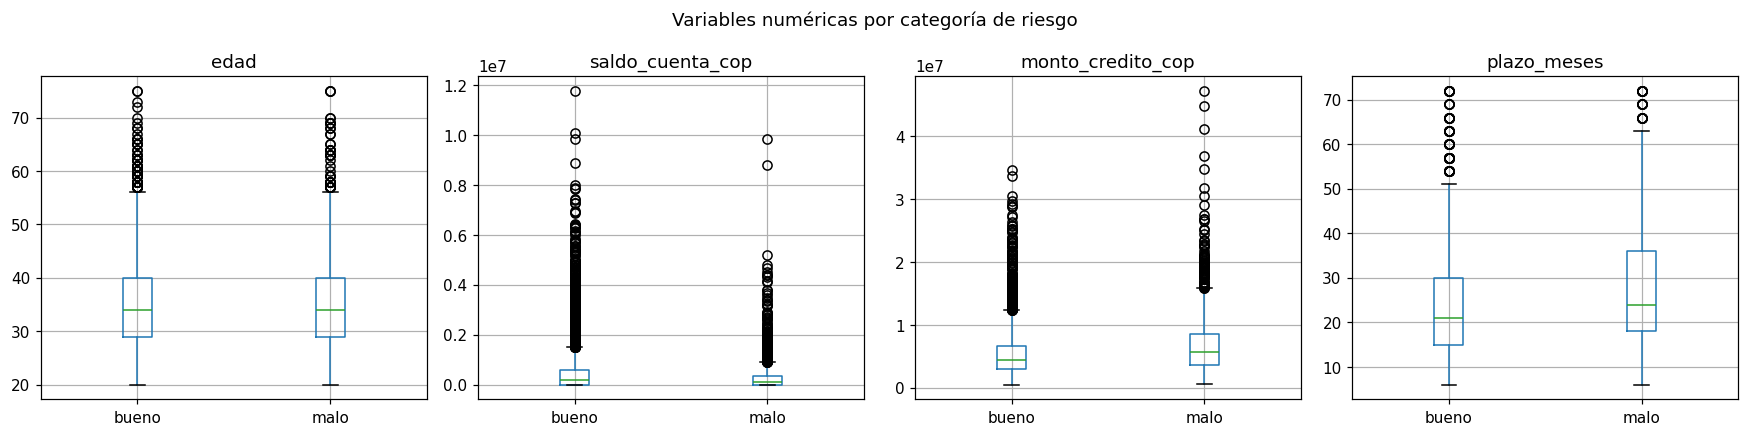

In [10]:
# Numéricas: boxplot de cada variable, separado por riesgo
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by="riesgo", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Variables numéricas por categoría de riesgo")
fig.tight_layout()
plt.show()


## 5. Correlaciones entre variables numéricas

Revisamos correlaciones antes de modelar porque, aunque una correlación alta
entre dos predictores (multicolinealidad) no rompe un SVM de la misma forma
en que rompería una regresión lineal, vale la pena tenerla documentada. En
particular, la correlación entre plazo y monto ya la diseñamos a propósito
(cerca de 0.62, ver Sección 3.3 del notebook de construcción).

In [11]:
corr = df[num_cols].corr()
corr


,edad,saldo_cuenta_cop,monto_credito_cop,plazo_meses
edad,1.000000,0.016703,-0.006915,0.001224
saldo_cuenta_cop,0.016703,1.000000,0.015204,0.023725
monto_credito_cop,-0.006915,0.015204,1.000000,0.178234
plazo_meses,0.001224,0.023725,0.178234,1.000000


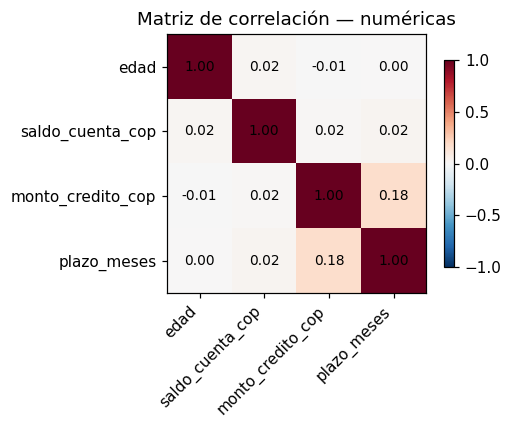

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, shrink=0.8)
ax.set_title("Matriz de correlación — numéricas")
fig.tight_layout()
plt.show()


## 6. Verificación de que la simulación reproduce lo planeado

Contrastamos contra un criterio de aceptación que fijamos de antemano en la
Primera entrega (rango 20%-25% de "malo", cuatro relaciones monótonas
específicas). Es la diferencia entre mirar los datos y verificar que los
datos cumplen lo que prometimos que iban a cumplir, que es justo el criterio
central de la rúbrica de la Segunda entrega para la consolidación de
datos.

In [13]:
prop_riesgo = df["riesgo"].value_counts(normalize=True)
cumple_balance = 0.20 <= prop_riesgo["malo"] <= 0.25
print("Balance de clases:", prop_riesgo.round(4).to_dict())
print(f"¿Cumple el rango planeado (20%-25% de 'malo')?: {cumple_balance}")


Balance de clases: {'bueno': 0.7726, 'malo': 0.2274}
¿Cumple el rango planeado (20%-25% de 'malo')?: True


In [14]:
def es_monotona(serie_ordenada, creciente=True):
    vals = serie_ordenada.values
    return all(vals[i] <= vals[i+1] for i in range(len(vals)-1)) if creciente \
        else all(vals[i] >= vals[i+1] for i in range(len(vals)-1))

q_monto = pd.qcut(df["monto_credito_cop"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
t_monto = df.groupby(q_monto, observed=True)["riesgo"].apply(lambda s: (s == "malo").mean())

q_plazo = pd.qcut(df["plazo_meses"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
t_plazo = df.groupby(q_plazo, observed=True)["riesgo"].apply(lambda s: (s == "malo").mean())

verificacion = pd.DataFrame({
    "relación esperada": [
        "sin cuenta -> mayor riesgo",
        "mora previa -> mayor riesgo",
        "mayor monto -> mayor riesgo",
        "mayor plazo -> mayor riesgo",
    ],
    "¿monótona?": [
        es_monotona(t_saldo),
        es_monotona(t_pago),
        es_monotona(t_monto),
        es_monotona(t_plazo),
    ],
})
verificacion


,relación esperada,¿monótona?
0,sin cuenta -> mayor riesgo,False
1,mora previa -> mayor riesgo,False
2,mayor monto -> mayor riesgo,True
3,mayor plazo -> mayor riesgo,True


## 7. Conclusiones del EDA

- **Duplicados:** no encontramos ninguno, ni por fila completa ni por `id`,
  y confirmamos que esta versión no tiene ningún valor faltante (0 celdas
  vacías en toda la base).
- **Outliers:** aparecen sobre todo en `monto_credito_cop` y
  `saldo_cuenta_cop`, coherentes con su forma log-normal por diseño; no
  recomendamos eliminarlos, sí usar un escalamiento adecuado en el
  `Pipeline`.
- **Balance de clases:** verificado dentro del rango 20%-25% que
  planeamos.
- **Relaciones documentadas:** las cuatro salieron monótonas en la dirección
  que esperábamos, la simulación sí reproduce la estructura que dijimos en la
  Primera entrega.
